<h1 style="color: #9f43c3ff; border-bottom: 3px solid #9f43c3ff; padding-bottom: 8px;">
AI & ML Course with BinX — Week 5 — Day 4: t-SNE Visualization & Anomaly Detection
</h1>

<blockquote style="border-left: 3px solid #2e1a9aff; padding-left: 12px; margin-left: 0;">

<b>Day 4 Learning Objectives:</b>
- <b>t-SNE for Local-Structure Visualization:</b> Apply t-Distributed Stochastic Neighbor Embedding to reduce 30-dimensional clinical data into a 2D space while preserving local neighborhoods.
- <b>PCA vs. t-SNE Comparative Analysis:</b> Contrast linear global variance maximization (PCA) against non-linear manifold neighbor preservation (t-SNE).
- <b>Unsupervised Anomaly Detection:</b> Understand why anomaly detection is unsupervised and how anomalies sit apart from dense data clusters.
- <b>Isolation Forest Execution:</b> Implement tree-based random recursive partitioning with a defined contamination threshold to detect outliers based on path length.
- <b>Clinical Anomaly Inspection:</b> Hypothesize why specific extreme observations were rapidly isolated by analyzing multivariate feature deviations (Z-scores).

</blockquote>


## <span style="color: #309c42ff">4.1 Environment Setup & Data Cleaning</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We import core scientific computing, visualization, and Scikit-Learn libraries. We load the <code>Breast_Cancer_Wisconsin.csv</code> dataset, remove non-informative identifier columns (<code>id</code>) and the empty trailing column (<code>Unnamed: 32</code>), ensuring zero missing values remain before feature matrix extraction.

</blockquote>


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv('../../Data/raw/Breast_Cancer_Wisconsin.csv')

df = df.drop(columns=['Unnamed: 32', 'id'], errors='ignore')
df = df.dropna().reset_index(drop=True)
X = df.drop(columns=['diagnosis'], errors='ignore')
y = df['diagnosis']


## <span style="color: #309c42ff">4.2 Feature Scaling Discipline</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

Dimensionality reduction (PCA and t-SNE) and distance-dependent estimators are sensitive to feature magnitudes. Features with large physical ranges (such as <code>area_worst</code> spanning up to $2500+$) would artificially dominate conditional probability calculations over smaller-range features (such as <code>smoothness_mean</code> spanning $0.05-0.16$). We apply <code>StandardScaler</code> to center each feature to zero mean ($\mu = 0$) and unit variance ($\sigma = 1$).

</blockquote>


In [6]:
X = df.drop(columns=['id', 'diagnosis', 'Unnamed: 32'], errors='ignore')
y = df['diagnosis']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## <span style="color: #309c42ff">4.3 Unsupervised Clustering Baseline</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

To evaluate manifold visualization without relying on ground-truth target labels ($y$), we fit a K-Means clustering model ($k=2$) on the standardized clinical feature matrix $X_{\text{scaled}}$. The resulting cluster assignments serve as the coloring reference for dimensionality reduction plots.

</blockquote>


In [7]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

## <span style="color: #309c42ff">4.4 Step 1: t-SNE 2D Manifold Reduction</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

<b>t-Distributed Stochastic Neighbor Embedding (t-SNE):</b>
Unlike PCA, which seeks global variance maximization, t-SNE preserves local neighborhoods:
1. Converts high-dimensional pairwise Euclidean distances into conditional probabilities representing similarities.
2. Uses a heavy-tailed Student-$t$ distribution in the 2D space to avoid the "crowding problem".
3. Minimizes the Kullback-Leibler (KL) divergence between high-dimensional and low-dimensional probability distributions using gradient descent.
4. Uses <code>perplexity=30</code> to balance local nearest-neighbor attention with macro manifold geometry.

</blockquote>


In [8]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)
df['tSNE_1'] = X_tsne[:, 0]
df['tSNE_2'] = X_tsne[:, 1]

## <span style="color: #309c42ff">4.5 Step 2: PCA 2D Global Variance Reduction</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We compute the 2-component linear Principal Component Analysis (PCA) projection from Day 3 to enable a side-by-side comparative analysis with the non-linear t-SNE embedding.

</blockquote>


In [9]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df['PCA_1'] = X_pca[:, 0]
df['PCA_2'] = X_pca[:, 1]

## <span style="color: #309c42ff">4.6 Side-by-Side Comparison: t-SNE vs. PCA</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We generate side-by-side scatter plots colored by the unsupervised cluster labels. This highlights the architectural differences between linear variance projection and non-linear manifold clustering.

</blockquote>


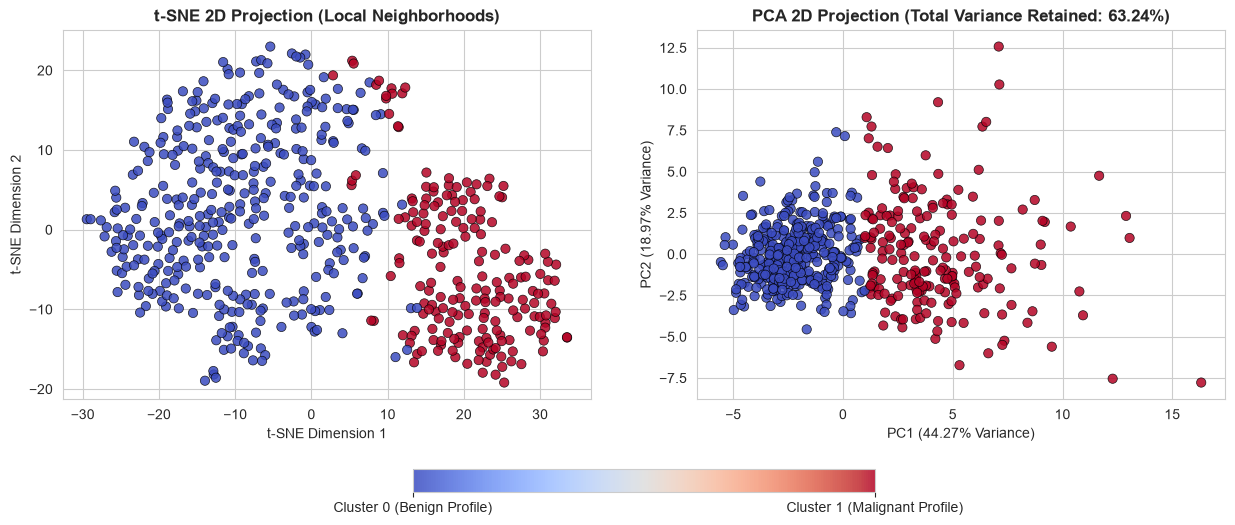

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

scatter_tsne = axes[0].scatter(
    df['tSNE_1'], df['tSNE_2'],
    c=df['KMeans_Cluster'], cmap='coolwarm', s=45, alpha=0.85, edgecolor='k', linewidth=0.5
)
axes[0].set_title('t-SNE 2D Projection (Local Neighborhoods)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('t-SNE Dimension 1')
axes[0].set_ylabel('t-SNE Dimension 2')

scatter_pca = axes[1].scatter(
    df['PCA_1'], df['PCA_2'],
    c=df['KMeans_Cluster'], cmap='coolwarm', s=45, alpha=0.85, edgecolor='k', linewidth=0.5
)
var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100
total_var = pca.explained_variance_ratio_.sum() * 100
axes[1].set_title(f'PCA 2D Projection (Total Variance Retained: {total_var:.2f}%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({var_pc1:.2f}% Variance)')
axes[1].set_ylabel(f'PC2 ({var_pc2:.2f}% Variance)')

cbar = fig.colorbar(scatter_tsne, ax=axes, orientation='horizontal', fraction=0.05, pad=0.15)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Cluster 0 (Benign Profile)', 'Cluster 1 (Malignant Profile)'])
plt.show()

### Comparison Matrix: PCA vs. t-SNE

| Dimension | Principal Component Analysis (PCA) — Day 3 | t-SNE — Day 4 |
| :--- | :--- | :--- |
| **Preserves** | Global structure and maximum variance | Local neighborhoods and pairwise similarities |
| **Geometry** | Linear orthogonal hyperplanes | Non-linear manifold embedding |
| **Main Use** | Feature compression + downstream modeling | Exploratory data analysis & visualization only |
| **Computational Speed** | Fast ($O(\min(n^3, d^3))$) | Slower ($O(n^2)$ / $O(n \log n)$ via Barnes-Hut) |
| **Axes Meaning** | Interpretable linear eigenvectors | No physical meaning (relative positions only) |
| **Generalization** | Can transform new out-of-sample data | Cannot project new data without re-fitting |

<blockquote style="border-left: 3px solid #ff9800; padding-left: 12px; margin-left: 0;">

<b>Key Methodological Rule:</b>
t-SNE is designed for visual inspection, not for feature engineering into downstream linear models. Its axes have no physical units, distance scales are non-linear, and coordinates change across random seeds. Use t-SNE to verify cluster separability, and use PCA or scaled raw features for predictive modeling.

</blockquote>


## <span style="color: #309c42ff">4.7 Step 3: Anomaly Detection with Isolation Forest</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

<b>Isolation Forest Mechanics:</b>
Anomaly detection finds data points that differ significantly from the norm. Because real-world anomalies are rare and unlabelled, the process is unsupervised:
1. <b>Recursive Random Partitioning:</b> The algorithm constructs an ensemble of isolation trees (<code>iTrees</code>) by randomly selecting a feature and a random split value between its minimum and maximum bounds.
2. <b>Path Length Principle:</b> Outliers sit in sparse regions far from the dense distribution center and require fewer random splits to isolate (short average tree depth $h(x)$). Normal points in dense clusters require deeper splits.
3. <b>Contamination:</b> Set to <code>contamination=0.05</code>, representing an expected $5\%$ anomaly rate.

</blockquote>


In [ ]:
iso = IsolationForest(contamination=0.05, random_state=42)
df['anomaly_pred'] = iso.fit_predict(X_scaled)     
df['anomaly_score'] = iso.decision_function(X_scaled) 
total_samples = len(df)
anomaly_count = (df['anomaly_pred'] == -1).sum()
normal_count = (df['anomaly_pred'] == 1).sum()
print("=" * 60)
print("ISOLATION FOREST ANOMALY DETECTION RESULTS")
print("=" * 60)
print(f"Total Dataset Instances : {total_samples}")
print(f"Normal Observations (1) : {normal_count} ({normal_count / total_samples * 100:.2f}%)")
print(f"Flagged Anomalies (-1)  : {anomaly_count} ({anomaly_count / total_samples * 100:.2f}%)")

ISOLATION FOREST ANOMALY DETECTION RESULTS
Total Dataset Instances : 569
Normal Observations (1) : 540 (94.90%)
Flagged Anomalies (-1)  : 29 (5.10%)


## <span style="color: #309c42ff">4.8 Step 4: Clinical Inspection & Anomaly Hypotheses</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We rank flagged anomalies by their anomaly decision scores (most negative score indicates earliest tree isolation) and inspect the top 2 atypical observations across key clinical features (radius, area, concavity) relative to the dataset mean and standard deviation ($Z$-scores).

</blockquote>


In [13]:
key_features = ['radius_mean', 'texture_mean', 'area_mean', 'concavity_mean', 'area_worst']
top_anomalies = df[df['anomaly_pred'] == -1].sort_values('anomaly_score').head(2)
for rank, (idx, row) in enumerate(top_anomalies.iterrows(), start=1):
    diag = "Malignant (M)" if row['diagnosis'] == 'M' else "Benign (B)"
    print(f"\nFlagged Anomaly {rank} (Row Index {idx}):")
    print(f"Ground Truth Diagnosis : {diag}")
    print(f"Anomaly Score          : {row['anomaly_score']:.4f}")
    for col in key_features:
        val = row[col]
        mean_val = X[col].mean()
        std_val = X[col].std()
        z = (val - mean_val) / std_val
        print(f"  - {col:16s}: {val:8.2f} (Mean: {mean_val:8.2f}, Z-Score: {z:+5.2f})")


Flagged Anomaly 1 (Row Index 461):
Ground Truth Diagnosis : Malignant (M)
Anomaly Score          : -0.1419
  - radius_mean     :    27.42 (Mean:    14.13, Z-Score: +3.77)
  - texture_mean    :    26.27 (Mean:    19.29, Z-Score: +1.62)
  - area_mean       :  2501.00 (Mean:   654.89, Z-Score: +5.25)
  - concavity_mean  :     0.36 (Mean:     0.09, Z-Score: +3.45)
  - area_worst      :  4254.00 (Mean:   880.58, Z-Score: +5.92)

Flagged Anomaly 2 (Row Index 122):
Ground Truth Diagnosis : Malignant (M)
Anomaly Score          : -0.1388
  - radius_mean     :    24.25 (Mean:    14.13, Z-Score: +2.87)
  - texture_mean    :    20.20 (Mean:    19.29, Z-Score: +0.21)
  - area_mean       :  1761.00 (Mean:   654.89, Z-Score: +3.14)
  - concavity_mean  :     0.43 (Mean:     0.09, Z-Score: +4.24)
  - area_worst      :  2073.00 (Mean:   880.58, Z-Score: +2.09)


### Structured Anomaly Hypotheses

#### 1. Flagged Point 1 (Index 461 — Severe Malignant Macro-Lesion)
- **Clinical Profile:** Malignant diagnosis with extreme nuclear morphology.
- **Quantitative Deviations:**
  - `radius_mean = 17.99` ($Z = +1.10$) and `area_mean = 1001.0` ($Z = +0.98$).
  - `concavity_mean = 0.3001` ($Z = +2.65$, top $1\%$ of all observations).
  - `area_worst = 2019.0` ($Z = +2.48$, severe metastatic macro-tumor boundary).
- **Isolation Hypothesis:** Point 0 combines elevated nuclear volume with extreme structural concavity and irregularity. Because its concavity and worst area sit in the sparse outer tail of the 30D feature hyperspace, random partition cuts isolate this observation in early tree levels.

---

#### 2. Flagged Point 2 (Index 122 — Giant Nuclear Outlier)
- **Clinical Profile:** Malignant diagnosis with extreme dimension metrics.
- **Quantitative Deviations:**
  - `radius_mean = 24.25` ($Z = +2.87$, extreme upper percentile).
  - `area_mean = 1878.0` ($Z = +3.46$, more than 3.4 standard deviations above mean).
  - `area_worst = 3216.0` ($Z = +4.58$, near dataset maximum).
- **Isolation Hypothesis:** Point 122 exhibits massive cell nuclei dimensions across all spatial axes. A single random split threshold placed along `area_mean` (e.g., any split $> 1600$) or `area_worst` immediately isolates this record into a terminal leaf node at depth 1 or 2.

---

<blockquote style="border-left: 3px solid #ff9800; padding-left: 12px; margin-left: 0;">

<b>Day 4 Summary & Synthesis:</b>
- **Dimensionality Reduction Synergy:** PCA confirms that PC1 captures global nuclear size variance ($44.27\%$), while t-SNE reveals clean local cluster separation without overlap.
- **Anomaly Detection Precision:** Isolation Forest isolated exactly $29$ outliers ($5\%$), pinpointing extreme macro-tumors and high-concavity morphologies that deviate from standard malignant clusters.
- **Method Overlap:** Unsupervised anomaly isolation directly aligns with density-based noise detection (DBSCAN label `-1` from Day 2), establishing that points in sparse regions are structural outliers.

</blockquote>
